In [1]:
from simplex import Simplex
import l1_svm
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np

Toda el codigo de este ejercicio esta implementado en dos modulos: `simplex.py` y `l1_svm.py`. En este notebook se muestran ejemplos de como usar las funciones implementadas en dichos modulos, y se detalla la logica utilizada en algunas de las funciones mas importantes.

## Modulo `Simplex`

Este modulo implementa una clase llamada Simplex que recibe una matriz de simplex primal, (maximizacion con restricciones de holgura), y a partir de ella podemos acceder a diferentes metodos para resolver los diferentes tipos de algoritmos simplex.

_La matriz de simplex primal tiene la siguiente forma:_


$$
\begin{aligned}
\arg\max_{\mathbf{x}}\quad & z = \sum_i c_i x_i \\
\text{sujeto a}\quad & \sum_i a_{ji} x_i \le b_j,\quad \forall j\\
& x_i \ge 0,\quad \forall i
\end{aligned}
\quad\Rightarrow\quad
\begin{cases}
z - \mathbf{c}^\top \mathbf{x} = 0,\\[0.3em]
\mathbf{A}\mathbf{x} = \mathbf{b},\\[0.3em]
\mathbf{x} \ge 0
\end{cases}
\quad\Rightarrow\quad
\left[
\begin{array}{ccc}
1 & -\mathbf{c}^\top & 0 \\[0.3em]
0 & \mathbf{A} & \mathbf{b}
\end{array}
\right]
$$


In [2]:
# Ejemplo

ejemplo = [
    [1, -3, -5, 0, 0, 0],   # función objetivo: Z = 3x1 + 5x2
    [0, 2, 1, 1, 0, 12],    # restricción 1
    [0, -1, 1, 0, 1, 3]     # restricción 2
]

ejemplo = np.array(ejemplo, dtype=float)

In [3]:
s1 = Simplex(ejemplo)

In [4]:
print(s1.original_matrix)

[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]


###  `iterate(self, type, return_extra_info=False):`

A continuacion un ejemplo de como se puede usar para realizar iteraciones de simplex tanto primal como dual:

In [5]:
s1 = Simplex(ejemplo)
print("Antes de la iteración:")
print(s1.original_matrix)
base, arguments, point, objective_value = s1.iterate(version='primal', return_extra_info=True)
print("\n Después de la iteración:")
print(s1.current_matrix.round(2))

print("-"*30)
print("Información extra:")
print("Base:", base)
print("Argumentos:", arguments)
print("Punto:", point)
print("Valor objetivo:", objective_value)

Antes de la iteración:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 Después de la iteración:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]
------------------------------
Información extra:
Base: [1, 2]
Argumentos: [3. 9.]
Punto: [0, 3.0]
Valor objetivo: 15.0


Observamos que ha cambiado la base de: $B_0 = \{s_1, s_2\} \Rightarrow B_1 = \{x_2, s_2\}$ y a realizado la iteraion correspondiente de simplex primal, de igual manera se puede utilizar para simplex dual:

###  `solver(self, version, printear_intermedios = True, return_history = False):`

Itera segun la version del simplex, hasta que se cumpla la condicion de parada correspondiente.

`printer_intermedios`: Hace un resumen de lo que pasa en cada iteracion. <br>
`return_history`: Devuelve un hitorial con lo que ocurrio en cada iteracion.

In [6]:
s1 = Simplex(ejemplo)
history = solution = s1.solver(version='primal', printear_intermedios=True, return_history=True)

------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3]
- Argumentos actuales: [12.  3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 2]
- Argumentos actuales: [3. 9.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 15.0

 - Matriz actual:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 2
- Base actual: [0 1]
- Argume

In [7]:
history

[{'iteration': 0,
  'base': array([2, 3]),
  'arguments': array([12.,  3.]),
  'point': array([0., 0.]),
  'objective_value': array(0.)},
 {'iteration': 1,
  'base': array([1, 2]),
  'arguments': array([3., 9.]),
  'point': array([0., 3.]),
  'objective_value': array(15.)},
 {'iteration': 2,
  'base': array([0, 1]),
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': array(39.)},
 {'iteration': 3,
  'base': array([0, 1]),
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': array(39.)}]

Ademas este historico se puede plotear usando la funcion `plot_sol_history(self, size=n)`, pero solo para problemas con dos variables.

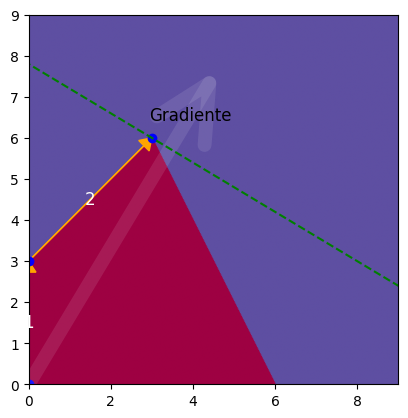

In [8]:
s1.plot_sol_history(size=9)

###  `transform_to_dual()`

Ademas hemos implementado un metodo que nos permite transformar un problema de simplex primal en su verision dual, usamos como ejemplo el problema del examen.

In [9]:
ejemplo_examen = [
    [1, -1, 0, 0, 0, 0],
    [0, 2, 1, 1, 0, 10],
    [0, -1, -1, 0, 1, -3]
]

ejemplo_examen = np.array(ejemplo_examen, dtype=float)

In [10]:
print("Matriz primal:")
s1 = Simplex(ejemplo_examen)
s2 = Simplex(ejemplo_examen)
print(s1.original_matrix)
s2.transform_to_dual()
print("\n Matriz dual:")
print(s2.current_matrix)

Matriz primal:
[[ 1. -1.  0.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 Matriz dual:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]


Luego ambos problemas pueden ser resueltos con el mismo objeto `Simplex`, usando el metodo `solver` y especificando la version que queremos usar.

In [11]:
s1.combined_solver()
history = s2.solver(version='dual', printear_intermedios=False, return_history=True)

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3]
- Argumentos actuales: [10. -3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 2]
- Argumentos actuales: [3. 7.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1.  1.  0.  0.  0.  0.]
 [ 0.  1.  1.  0. -1.  3.]
 [ 0.  1.  0.  1.  1.  7.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
------------------------------------------------------------
-------------------ITERANDO CON EL PRIMAL---

Y plotear el historial del dual.

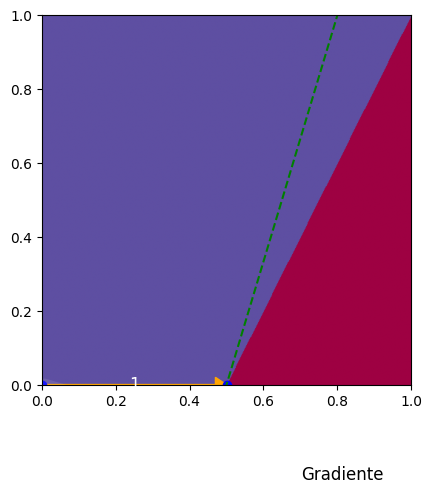

In [12]:
s2.plot_sol_history(size=1)

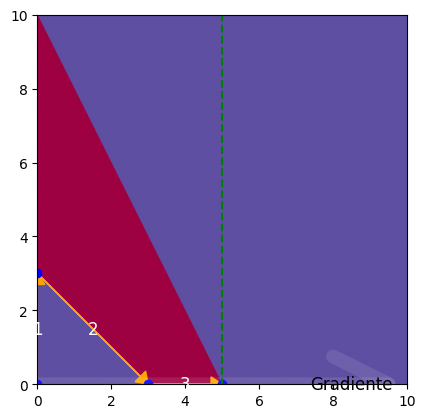

In [13]:
s1.plot_sol_history()

Ademas, utilizando las condiciones de holguras complementarias y el teorema de dualidad fuerte, podemos recuperar la solucion primal a partir de la solucion dual, usando el metodo <br>
 ### `get_primal_solution_from_dual_solution(printear = True)`.

In [14]:
primal_sol = s2.get_primal_solution_from_dual_solution(printear = True)

------------------------------------------------------------
Solución del problema primal obtenida desde la solución del dual:
Base primal: [3 0]
Punto primal: [5. 0.]
Valor objetivo: 5.0
------------------------------------------------------------


In [15]:
print("solucion primal recuperado:", primal_sol)
print("solucion primal directo:", s1.point)

print("Valor objetivo primal recuperado:", s2.objective_value)
print("Valor objetivo primal directo:", s1.objective_value)

solucion primal recuperado: [5.0, 0]
solucion primal directo: [5.0, 0]
Valor objetivo primal recuperado: 5.0
Valor objetivo primal directo: 5.0


Ambos resultados coinciden, ahora podemos elegir cual de los metodos usar para ahorrar iteraciones o disminuir el numero de restricciones para evitar hacer inversas de matrices muy grandes.
por ejemplo en el caso del examen, se podia resolver pasando al problema dual, en una sola iteracion.

### `combined_solver()`

Este metodo implementa el algoritmo del simplex combinado, y lo usamos para un problema donde el origen de coordenadas sea no factible para simplex primal.

In [16]:
ejemplo_dual = [
    [1, -3, -2, 0, 0, 0, 0, 0, 0],
    [0, -1, -1, 1, 0, 0, 0, 0, -2],
    [0, 1, 2, 0, 1, 0, 0, 0, 8],
    [0, 2, 1, 0, 0, 1, 0, 0, 8],
    [0, 1, -1, 0, 0, 0, 1, 0, 1],
    [0, -1, 1, 0, 0, 0, 0, 1, 1]
]

ejemplo_dual = np.array(ejemplo_dual, dtype=float)

In [17]:
s1 = Simplex(ejemplo_dual)
s1.combined_solver()

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3 4 5 6]
- Argumentos actuales: [-2.  8.  8.  1.  1.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]

 - Matriz original:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 3 4 5 6]
- Argumentos actuales: [ 2.  4.  6.  3. -1.]
- Punto actual: [0

/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:84: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


ploteamos el historial que se ha generado.

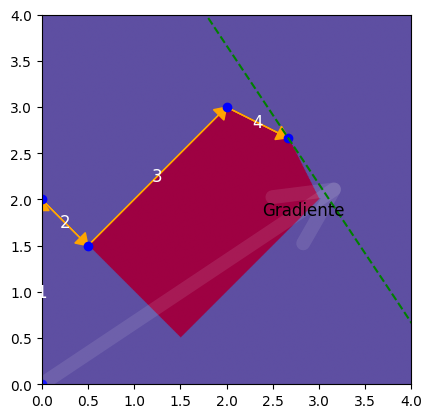

In [18]:
s1.plot_sol_history(size=4)

## Modulo `l1_svm`

Este modulo hace uso de la clase `Simplex` para implementar un clasificador SVM eligiendo la norma L1 en lugar de la norma L2 habitual.

### `generar_datos_svm(n_samples=N, random_state=SEED)`

Genera un conjunto de datos aleatorios para entrenar un clasificador SVM, se generan con centros separados, pero no tienen por que se linealmente separables.

In [19]:
X, y = l1_svm.generar_datos_svm(100, random_state=42)

In [20]:
DataFrame(np.concatenate((X, y.reshape(-1, 1)), axis=1), columns=['X1', 'X2', 'Y'])

,X1,X2,Y
0,-3.707133,8.550139,-1.0
1,7.347507,4.607675,1.0
2,-3.870154,9.291593,-1.0
3,6.695029,6.715152,1.0
4,5.208529,5.241027,1.0
...,...,...,...
95,0.068301,11.342486,-1.0
96,-0.220692,9.836164,-1.0
97,2.522895,-1.813948,1.0
98,-3.058377,9.907068,-1.0


### `generate_svm_matrix(X, y, C)`

Genera la matriz de simplex primal correspondiente al problema L1-SVM, a partir de los datos de entrada `X` e `y`, y el parametro de `C`.

In [21]:
C = 0.1

DataFrame(l1_svm.generate_svm_matrix(X, y, C))

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,1.0,0.500000,0.500000,0.500000,0.500000,0.0,0.0,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0
1,0.0,-3.707133,8.550139,3.707133,-8.550139,1.0,-1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,0.0,-7.347507,-4.607675,7.347507,4.607675,-1.0,1.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,0.0,-3.870154,9.291593,3.870154,-9.291593,1.0,-1.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
4,0.0,-6.695029,-6.715152,6.695029,6.715152,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.068301,11.342486,-0.068301,-11.342486,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0
97,0.0,-0.220692,9.836164,0.220692,-9.836164,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.0
98,0.0,-2.522895,1.813948,2.522895,-1.813948,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0
99,0.0,-3.058377,9.907068,3.058377,-9.907068,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0


### `solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True):`

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205]
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
- Punto act

/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:117: RuntimeWarning: overflow encountered in divide
  cocients = np.abs(numerators[mask] / denominators[mask])


[[ 1.    0.   -1.   ...  0.   -0.    2.07]
 [ 0.    1.    0.   ...  0.    0.    0.15]
 [ 0.    0.   -1.   ...  0.    0.    0.04]
 ...
 [ 0.    0.    0.   ...  0.    0.   -0.49]
 [ 0.    0.   -0.   ...  1.    0.   -0.06]
 [ 0.    0.    0.   ...  0.    1.   -0.21]]

 - Matriz original:
[[ 1. -0. -0. ... -0. -0. -0.]
 [ 0. -4.  9. ...  0.  0. -1.]
 [ 0. -7. -5. ...  0.  0. -1.]
 ...
 [ 0. -3.  2. ...  0.  0. -1.]
 [ 0. -3. 10. ...  1.  0. -1.]
 [ 0. -2.  8. ...  0.  1. -1.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 73
- Base actual: [  0   3   4   6   8   9  10  11  12  13  14  15  16  17  18  20  21  22
  23  24  25  26  27  28  30  31  32  33  34  35  36  37  38  39  40  41
  42  43  44  45  46  48  49  50  51  53  54  55  57  58  60  64  65  69
  71  74  84  85  88  90  95 103 107 119 129 147 156 159 161 162 163 166
 167 168 170 172 173 175 176 178 179 180 181 182 183 186 187 191 192 193
 194 

/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:84: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]
/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:84: RuntimeWarning: overflow encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


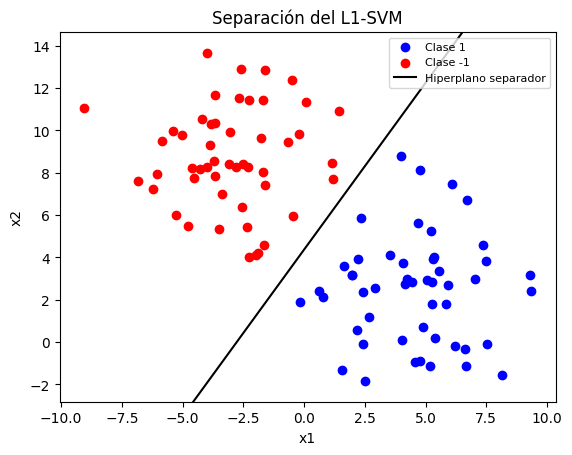

Accuracy = 1.0


In [22]:
l1_svm.solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True)

Por ultimo un ejemplo con datos generados aleatoriamente cada vez que se ejecuta la celda.

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205]
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
- Punto act

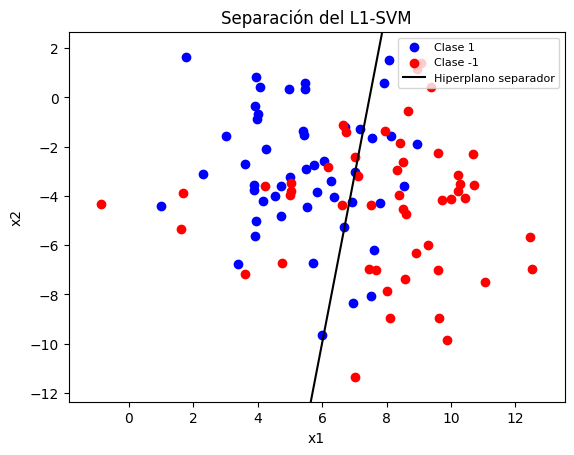

Accuracy = 0.75


In [42]:
from random import randint

SAMPLES = 100

X, y = l1_svm.generar_datos_svm(n_samples=SAMPLES, random_state=randint(1, 1000))
l1_svm.solve_simplex_svm(X, y, C=0.1, print_sol=True, plot=True, print_acc=True)
